In [6]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from dataclasses import replace

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.img_converter import ImgConverter
from converters.line_heuristics.line_converter import LineConverter
from converters.tile.bin_1d import Tile2Symb1dBin

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
MAX_COLS = 20
MAX_LINES = 10
NUM_IMGS = 10
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


def make_converter(params: Params):
    converter = LineConverter(tile_converter=Tile2Symb1dBin(symbols=SYMBOLS,
                                                            font=FONT,
                                                            **params.converter_args))

    return ImgConverter(converter, FONT)

In [7]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery

default_params = Params(max_cols=MAX_COLS,
                        max_lines=MAX_LINES,
                        font_path=FONT_PATH,
                        font_size=FONT_SIZE)

converter = make_converter(default_params)

line_height = int(default_params.font_size * 1.333)
col_width = int(line_height / 2)

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    col_width=col_width,
                                    line_height=line_height,
                                    gens_per_step=default_params.gens_per_step)
    results.append(res_arr)

print_gallery(results, 3)

----------------------------------------------------------------------
| _~,~~=rx|/,;>;/\":~' | 2#9R$X8k(QA%@%W@]RQA | 7}}Cc=~~+Ljun=5VI7", |
| E&9gOg8q6&Ub6qCC24nu | =<JhmNRT=7+kqS/t()l/ | (7l!+;>+=t*/++_~^:^~ |
| gQ%%$8K0mQ$%%Q%QQ%Oq | )4VaB8s/,'``no}y39Fl | rJxna4p6&QwXpT*EQORb |
| DQQM0!CztZ$%$$Q0NmGE | *TjyO%B{~ ..(UEd]Iau | rltx++\7|v5Tv)*!-+i^ |
| GmQ%$Q%QQQ$%QQQ$GmbS | rFXdAGDd=' .*p5dG6ar | ll7r('->,\~ "`~:!,+> |
| #$@M@MW@@M@M$%%$wwH2 | e5fkEDO8n',x=:-rYool | <;v>:-/!!--=xcE&bb8d |
| -"~:-~:^~:-^~^-~ ``  |  . `'.'".' '```.`''` | `.``` `  ''''` ' '`  |
----------------------------------------------------------------------
-----------------------------------------------------------------
|  .'  ' ^``  .'` | %88B#8%%UeVg$Wgs4AOG | &61J(\>eV11AeI&hasY; |
| "~,_-:~~"-,---` | Q$$$NVP9$RO9AEH9qm%% | dXfhaV2(;\|cYL>vz>v* |
| yyyZTTIV{3s{Ty, | {g%MW$%GR65;!x|" _=U | H6A{|?7lxLLXp[n(vx[i |
| P9bpd6&bEbP9EE^ | dsK$W$BNY.`>>.  .`'' | KGBR6K97-'=s9S6OKF}u |
| jHdpUteh>]qqdU, | x[vlfnIRtni

Min: 0.0363 | Max: 0.0710 | Mean: 0.0518 | Std: 0.0094
Min: 0.0550 | Max: 0.1211 | Mean: 0.0923 | Std: 0.0221
Min: 0.0271 | Max: 0.1660 | Mean: 0.1074 | Std: 0.0358
Min: 0.0614 | Max: 0.1541 | Mean: 0.1108 | Std: 0.0249
Min: 0.0589 | Max: 0.1551 | Mean: 0.1138 | Std: 0.0283
Min: 0.0578 | Max: 0.1449 | Mean: 0.1078 | Std: 0.0257
Min: 0.0462 | Max: 0.1628 | Mean: 0.1125 | Std: 0.0347
Min: 0.0403 | Max: 0.1778 | Mean: 0.1092 | Std: 0.0362
Min: 0.0534 | Max: 0.1718 | Mean: 0.1096 | Std: 0.0338


C:\Users\wojte\AppData\Local\Temp\ipykernel_22860\264104810.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


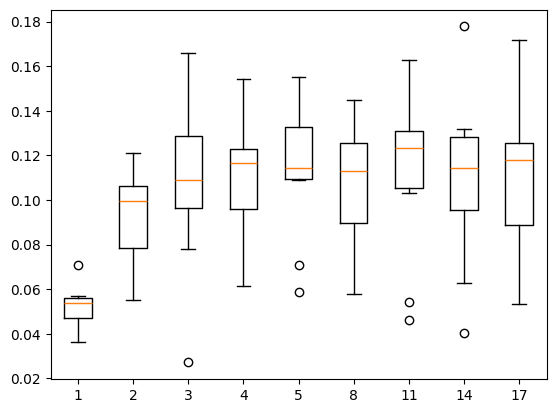

In [8]:
# bins

params_space = [
    bins for bins in range(1, 5, 1)
]
params_space += [
    bins for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: replace(default_params, converter_args={'bins': bins}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: 0.0471 | Max: 0.1142 | Mean: 0.0774 | Std: 0.0199
Min: 0.0415 | Max: 0.1474 | Mean: 0.0972 | Std: 0.0284
Min: 0.0577 | Max: 0.1513 | Mean: 0.1131 | Std: 0.0286
Min: 0.0500 | Max: 0.1986 | Mean: 0.1299 | Std: 0.0400
Min: 0.0634 | Max: 0.1982 | Mean: 0.1389 | Std: 0.0392


C:\Users\wojte\AppData\Local\Temp\ipykernel_22860\2305421242.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


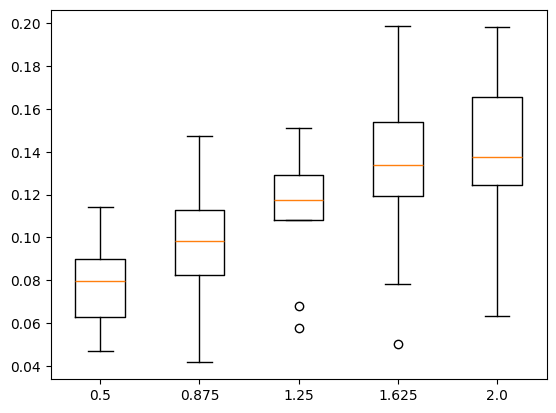

In [9]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: replace(default_params, preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

Min: 0.0733 | Max: 0.1432 | Mean: 0.1064 | Std: 0.0217
Min: 0.0421 | Max: 0.1021 | Mean: 0.0767 | Std: 0.0197
Min: 0.0098 | Max: 0.2507 | Mean: 0.1188 | Std: 0.0709


C:\Users\wojte\AppData\Local\Temp\ipykernel_22860\1162874657.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


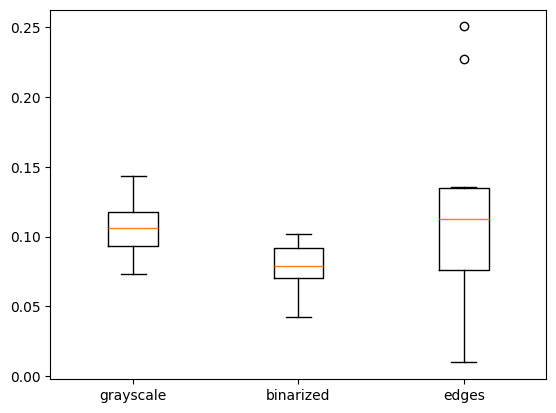

In [10]:
params_space = [default_params]
similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
             for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_BIN_PATHS, make_converter, params_space)

IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
             for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_EDGE_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=['grayscale', 'binarized', 'edges'])
plt.show()